In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    generate_pred_datasets,
    optuna_search,
    predictions,
    training,
)
from src.utils import configure_logger

import pandas as pd
from qqe.src.experiments.plotting import view_correlation

logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [5]:
from typing import Any
import matplotlib.pyplot as plt

from qqe.src.GNN.training.utils import collect_dataset_paths
from qqe.src.GNN.training.runners import MODEL_REGISTRY
from qqe.src.GNN.training.train_config import TrainConfig

from collections.abc import Callable
Loader = Callable[..., Any]

In [6]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [8]:
def run(
    model_type,
    epochs,
    lr,
    loss_type,
    batch_size,
    training_mode,
    family,
    target,
    model_hparams,
    train_hparams,
    training_data_dir,
    model_save_path,
    plot_qubits=10,
    plot_layers=80,
):
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        model_type=model_type,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        training_data_dir=training_data_dir,
        model_save_path=model_save_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )
    training_scope = "family" if training_mode == "per_family" else "global"
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=plot_layers,
        plot_n_qubits=plot_qubits,
        split_by_family=True,
        show_progress=True,
    )

    df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)
    view_correlation(
        df,
        nq=plot_qubits,
        nl=plot_layers,
        col_x="target",
        col_y="prediction",
    )
    df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
    plt.figure(figsize=(8, 6))
    plt.scatter(df["target"], df["prediction"], alpha=0.7)
    plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
    plt.xlabel("True SRE")
    plt.ylabel("Predicted SRE")
    plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

2026-05-21 14:21:27,732 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-05-21 14:21:27,733 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-21 14:21:27,733 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-21 14:23:35,129 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-21 14:23:35,130 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-21 14:23:35,131 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-21 14:25:06,005 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-21 14:25:06,006 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-21 14:25:06,203 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  75%|███████▌  | 604/804 [01:00<00:21,  9.44it/s, loss=0.0040, graphs=19392]

2026-05-21 14:26:06,291 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 606/804 | loss 0.003985 | elapsed 60.1s | graphs 19392


2026-05-21 14:26:27,074 - qqe.src.GNN.training.train - INFO - Training complete (80.9s) | running validation...


2026-05-21 14:26:34,889 - qqe.src.GNN.training.train - INFO - Losses | train 0.003422 | val 0.000382 | lr 4.71e-05 | time train=80.9s val=7.8s total=88.7s
2026-05-21 14:26:34,892 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-21 15:10:27,004 - qqe.src.GNN.training.train - INFO - Losses | train 0.000047 | val 0.000037 | lr 4.71e-05 | time train=85.2s val=8.6s total=93.8s
2026-05-21 15:10:27,007 - qqe.src.GNN.training.train - INFO - -------- EPOCH 030 --------


Epoch 30/30:  68%|██████▊   | 549/804 [01:00<00:27,  9.24it/s, loss=0.0000, graphs=17600]

2026-05-21 15:11:27,042 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 550/804 | loss 0.000045 | elapsed 60.0s | graphs 17600


2026-05-21 15:11:54,292 - qqe.src.GNN.training.train - INFO - Training complete (87.3s) | running validation...


2026-05-21 15:12:02,401 - qqe.src.GNN.training.train - INFO - Losses | train 0.000045 | val 0.000038 | lr 2.36e-05 | time train=87.3s val=8.1s total=95.4s
2026-05-21 15:12:26,939 - qqe.src.GNN.training.runners - INFO - Training complete.


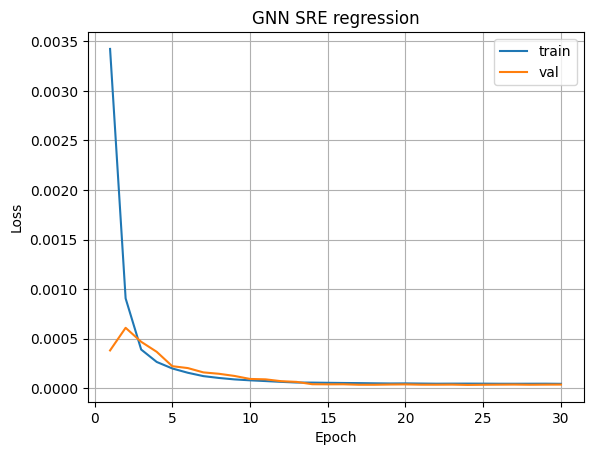

2026-05-21 15:12:27,158 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/id_random_model_gnn_per_family.pt
2026-05-21 15:12:27,161 - scripts.train_model - INFO - Final test loss: 0.000036
2026-05-21 15:12:27,162 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/id_random_model_gnn_per_family.pt
2026-05-21 15:13:03,229 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [12:28<00:00,  5.22batch/s]
2026-05-21 15:25:40,484 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-21 15:25:40,669 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-21 15:25:40,853 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


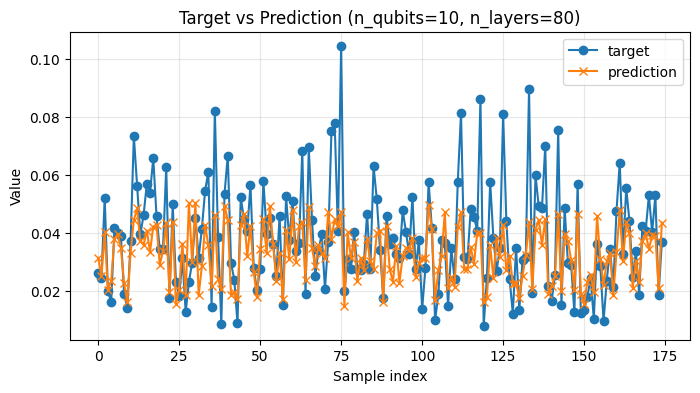

Pearson r = 0.7686


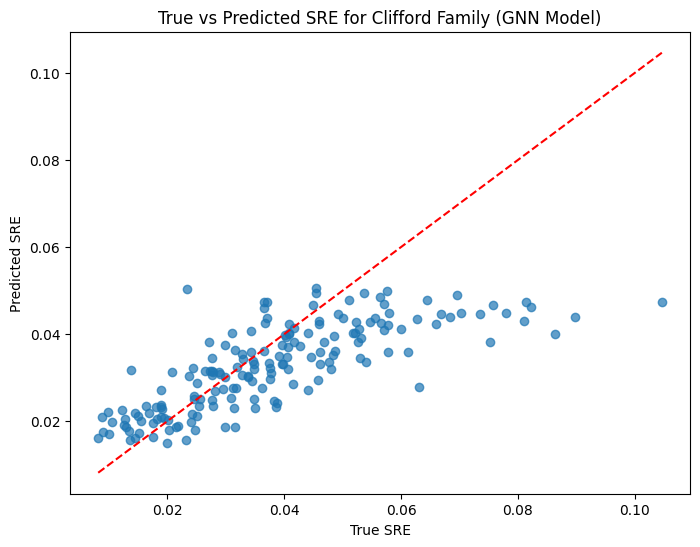

In [9]:
model_type="gnn"
epochs = 30
lr = 4.713739768368574e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"
model_save_path = f"../outputs/models/id_{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 64,
    "reg_hidden": 16,
    "num_layers": 6,
    "dropout_rate": 0.16706832478693956,
}

train_hparams = {
    "weight_decay": 0.0003546212126918109,
    "grad_clip": 0.031369743908464774,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

### Generate new datasets

In [ ]:
backend = "pennylane"
target = "SRE"
method = "fwht"
use_dask = True

output_dir = "outputs/data/new_dataset"
n_bins = 50
families = "random,clifford"
n_seeds_train = 150
n_seeds_pred = 50
qubit_min, qubit_max = 4, 30
layer_min, layer_max = 2, 100
step = 2
target_qubits = "4,6,8"
max_config = None
dask_workers = 4
dask_memory = "4GiB"

In [16]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds_train,
    prediction_n_seeds_option=n_seeds_pred,
    qubits_min=qubit_min,
    qubits_max=qubit_max,
    layers_min=layer_min,
    layers_max=layer_max,
    qubits_step=step,
    layers_step=step,
    target_qubits=target_qubits,
    max_configs=max_config,
    use_dask=use_dask,
    dask_n_workers=dask_workers,
    dask_memory_per_worker=dask_memory,
)

2026-05-21 16:26:33,280 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-21 16:26:33,464 - qqe.src.GNN.dataset_builder - INFO - Generated 107100 configs for random
2026-05-21 16:26:33,464 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-21 16:26:33,487 - distributed.scheduler - INFO - State start
2026-05-21 16:26:33,509 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:61735
2026-05-21 16:26:33,509 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-21 16:26:33,511 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-21 16:26:33,583 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:61740'
2026-05-21 16:26:33,586 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:61744'
2026-05-21 16:26:33,587 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:61742'
2026-05-21 16:26:33,590 

KeyboardInterrupt: 